# The matched filter: sKF for generalized Gaussian noise with $\beta^*$, against the Laplacian filters

Section 4 of the new draft keeps the Laplacian likelihood because, it says, the filter matched to the generalized Gaussian noise with $\beta^* = 0.2$ recovered from a change 1.2 to 2.2 times more slowly than the Laplacian filters. This notebook measures that: first at rest, then across an abrupt change of the response.

## 1. Imports

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter
from scipy.special import gammaln, log_ndtr
from scipy.stats import gennorm
import rir_generator as rir

NOTEBOOK_START = time.time()                   # for the total printed at the very end
print("imports ready")

imports ready


## 2. The scenario

Notebook 07's, unchanged: $M = 128$ room impulse response, AR($-0.9$) input, generalized Gaussian noise with $\beta^* = 0.2$ at SNR $= 5$ dB, $b_\eta = \mathrm{E}|\eta_t|$, $N = 96000$, $R = 20$.

In [2]:
# Copied from notebook 07, commit f26ed36.
M = 128                     # filter length / length of the impulse response
N = 96000                   # steps per run (12 s at 8 kHz, the span of Fig. 3a of the paper)
R = 20                      # independent realisations
WARMUP = 500                # AR samples discarded so the input starts stationary

# AR_A = 0.0 reproduces the white input of notebook 05; BETA = 1.0, with TARGET_DB = -15 in
# section 4, reproduces the Laplacian noise of notebook 06. The cache of section 4 keys on the
# b_eta convention alone, so change B_ETA_RULE or CACHE_PREFIX there as well when you change
# AR_A or BETA, or the sweep will load the results of another scenario.
AR_A = -0.9                 # AR(1) coefficient of the input
SNR_DB = 5.0                # nominal signal-to-noise ratio, as in Fig. 3 of the paper
BETA = 0.2                  # shape of the generalized Gaussian measurement noise
VAR_THETA_0 = 2.0           # initial prior variance on each weight, as in notebooks 01 and 02
FS = 8000                   # sampling rate [Hz], the rate of section 7.1 of the draft

# The room of section 7.1 of the draft, simulated with ref. [24] (image method).
ROOM = [5, 10, 6]           # room dimensions [m]
T60 = 0.2                   # reverberation time [s]
C_SOUND = 340               # speed of sound [m/s]
SRC = [1, 2.5, 2]           # source position [m]
MIC = [1, 1.5, 1]           # receiver position [m]

# Generated once and then fixed. Normalised to unit norm: misalignment is scale-invariant
# and SNR_DB is imposed below from P_signal, so the normalisation changes nothing except
# keeping the grid of section 4 on the scale notebook 03 tuned it at.
ho = rir.generate(c=C_SOUND, fs=FS, r=MIC, s=SRC, L=ROOM,
                  reverberation_time=T60, nsample=M).flatten()
ho = ho/np.linalg.norm(ho)

# Signal power, in closed form: r[k] = AR_A^|k| for a unit-variance AR(1) input.
lags = np.abs(np.subtract.outer(np.arange(M), np.arange(M)))
Rxx = AR_A**lags
P_signal = ho @ Rxx @ ho

var_eta = P_signal/10**(SNR_DB/10)                 # noise variance that gives SNR_DB

# Scale of the generalized Gaussian with variance var_eta:
# Var = scale^2 Gamma(3/beta)/Gamma(1/beta).
scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))


def laplace_scale(var_eta):
    """b_eta = E|eta_t| of the generalized Gaussian of variance var_eta: the Laplacian closest to it
    in KL(p || q), the direction of eq. (10), and its maximum-likelihood fit."""
    scale = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))   # generalized Gaussian scale
    return scale*np.exp(gammaln(2/BETA) - gammaln(1/BETA))               # E|eta| = scale Gamma(2/b)/Gamma(1/b)


b_eta = laplace_scale(var_eta)                     # the scale the filters are told
b_eta_variance = np.sqrt(var_eta/2)                # the scale notebooks 03-06 told them

print(f"signal power = {P_signal:.4f}")
print(f"var_eta      = {var_eta:.4e}   (nominal, at {SNR_DB:.0f} dB SNR)")
print(f"noise scale  = {scale_gg:.4e}   (generalized Gaussian, beta = {BETA})")
print()
print(f"b_eta = E|eta|     = {b_eta:.4e}   (used by the filters)")
print(f"sqrt(var_eta/2)    = {b_eta_variance:.4e}   (old convention, notebooks 03-06): "
      f"{b_eta_variance/b_eta:.2f}x larger")

# At beta = 1 the noise is already a Laplace, and matching E|eta| and matching the variance
# give the same scale. Anywhere else the two conventions part ways.
if BETA == 1.0:
    assert np.isclose(b_eta, b_eta_variance), f"{b_eta} is not {b_eta_variance} at beta = 1"

signal power = 0.8173
var_eta      = 2.5844e-01   (nominal, at 5 dB SNR)
noise scale  = 8.4350e-06   (generalized Gaussian, beta = 0.2)

b_eta = E|eta|     = 1.2754e-01   (used by the filters)
sqrt(var_eta/2)    = 3.5947e-01   (old convention, notebooks 03-06): 2.82x larger


`generate_signals(seed)` returns one realisation: the input `x`, the observation `d` and the noise `eta`.

In [3]:
# Copied from notebook 07, commit f26ed36.
def generate_signals(seed):
    """One realisation: AR(1) input, its clean output through ho, and heavy-tailed noise."""
    rng = np.random.default_rng(seed)
    u = np.sqrt(1 - AR_A**2)*rng.standard_normal(N + WARMUP)   # driving noise, unit-variance x
    x = lfilter([1.0], [1.0, -AR_A], u)[WARMUP:]               # x_t = AR_A x_{t-1} + u_t
    y = np.convolve(ho, x)[:N]                                 # clean output, y_t = x_t' ho
    eta = gennorm.rvs(BETA, scale=scale_gg, size=N, random_state=rng)
    return x, y + eta, eta


x, d, eta = generate_signals(0)
print("x:", x.shape, " d:", d.shape)
print(f"noise, first realisation: std {eta.std():.4f}, "
      f"median |eta| {np.median(np.abs(eta)):.5f}, max |eta| {np.abs(eta).max():.4f}")

# Control on b_eta: the sampled mean |eta| of this realisation against the closed form above.
print(f"mean |eta|, sampled     : {np.abs(eta).mean():.4e}   "
      f"against b_eta = {b_eta:.4e}, the closed form")

x: (96000,)  d: (96000,)
noise, first realisation: std 0.4831, median |eta| 0.01889, max |eta| 24.7659
mean |eta|, sampled     : 1.2807e-01   against b_eta = 1.2754e-01, the closed form


## 3. The four filters

The Gaussian, the minorized and the exact (joint) sKF of notebook 07, and the sKF matched to the true noise with the quadrature of notebook 08. $k_t = \sigma_t/\mathrm{E}|\eta_t|$ for all four.

### sKF (Gaussian), eqs. (35), (36) and (38) of the new draft

$$\sigma_t^2 = \tilde v_t\|x_t\|^2 \qquad \chi_t = \frac{\sigma_t^2}{\sigma_t^2 + v_\eta}\,e_t \qquad \chi_t' = \frac{\sigma_t^2}{\sigma_t^2 + v_\eta}$$

$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right)$$

with $v_\eta = \mathrm{Var}[\eta_t]$, the Gaussian closest to the true noise in KL. The code is the one of notebook 06.

In [4]:
# Copied from notebook 07, commit f26ed36.
def shift(new_x_sample, x_window):
    L = len(x_window)
    new_x_window = np.zeros(L)
    new_x_window[0] = new_x_sample
    new_x_window[1:] = x_window[:-1]
    return new_x_window


# Copied from notebook 06 (commit db4b3a9), same lines: only the comments now cite the new draft,
# and sigma_t is recorded for the k_t of the tables.
def sKF_gaussian(n, x, d, w0, parameters):
    """Eqs. (35), (36) and (38) of the new draft: Gaussian noise, chi_t linear in e_t."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    var_eta = parameters["var_eta"]                    # v_eta, observation noise variance
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps, eq. (36)
            power = x_t @ x_t                          # ||x_t||^2
            gain = v_tilde/(var_eta + v_tilde*power)   # chi'/||x||^2 = v_tilde/(v_eta + sigma^2), eq. (38)
            w = w + gain*x_t*e[k]                      # w = w + x_t chi/||x||^2, eqs. (35) and (38)
            v = v_tilde*(1 - gain*power/M)             # v = v_tilde (1 - chi'/M), eq. (36)
            sigma_hist[k] = np.sqrt(v_tilde*power)     # sigma_t, eq. (16), recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF (Gaussian) ready")

sKF (Gaussian) ready


### sKF-L (minorized), eqs. (robust.sKF.mean) and (robust.sKF.variance) of the old draft

The Gaussian sKF with $v_\eta \leftarrow b_\eta|e_t|$:

$$w_t = w_{t-1} + \frac{\tilde v_t\,x_t}{b_\eta|e_t| + \tilde v_t\|x_t\|^2}\,e_t
\qquad v_t = \tilde v_t\left(1 - \frac{1}{M}\frac{\tilde v_t\|x_t\|^2}{b_\eta|e_t| + \tilde v_t\|x_t\|^2}\right)$$

The same filter in the notation of the new Section 3.5:

$$\tau_t = \frac{\tilde v_t\|x_t\|^2}{b_\eta} \qquad \chi_t^{\min} = \frac{\tau_t e_t}{\tau_t + |e_t|} \qquad w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\chi_t^{\min} \qquad v_t = \tilde v_t\left(1 - \frac{1}{M}\frac{\chi_t^{\min}}{e_t}\right)$$

eq. (45) of the new draft; substituting $\tau_t$ gives exactly the form above.

In [5]:
# Copied from notebook 07, commit f26ed36.
def sKF_L_minorized(n, x, d, w0, parameters):
    """Eqs. (robust.sKF.mean) and (robust.sKF.variance): the sKF above with v_eta -> b_eta |e_t|."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            denominator = b_eta*abs(e[k]) + v_tilde*power     # b_eta |e_t| + v_tilde ||x_t||^2
            w = w + x_t*(v_tilde*e[k]/denominator)     # w = w + v_tilde x_t e_t / denominator
            v = v_tilde*(1 - v_tilde*power/(M*denominator))   # v = v_tilde (1 - v_tilde ||x||^2/(M den))
            sigma_hist[k] = np.sqrt(v_tilde*power)     # sigma_t, eq. (16), recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF-L (minorized) ready")

sKF-L (minorized) ready


### sKF-L (exact, joint), new draft, Section 3

$$\sigma_t^2 = \tilde v_t\|x_t\|^2 \qquad u_t = \frac{e_t}{\sigma_t} \qquad k_t = \frac{\sigma_t}{b_\eta} \qquad \tau_t = \frac{\sigma_t^2}{b_\eta}$$

$$R_t^\pm = \mathcal R(k_t \pm u_t), \quad \mathcal R(z) = \frac{\Phi(-z)}{\phi(z)} \qquad \Lambda_t = \frac{R_t^- - R_t^+}{R_t^- + R_t^+}$$

$$\chi_t = \tau_t\Lambda_t \qquad \chi_t' = \frac{2k_t}{R_t^- + R_t^+} - k_t^2\left(1-\Lambda_t^2\right)$$

$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right)$$

Equations (16), (39), (41), (43), (35) and (36) of the new draft.

Numerically, $\mathcal R$ only through its logarithm, $\log\mathcal R(z) = \log\Phi(-z) + z^2/2 + \tfrac12\log 2\pi$, and $\Lambda_t = \tanh\big((\log R_t^- - \log R_t^+)/2\big)$.

Same loop as the Gaussian sKF; the noise enters only through $\chi_t$ and $\chi_t'$.

In [6]:
# Copied from notebook 07, commit f26ed36.
def log_mills(z):
    """log R(z), with R(z) = Phi(-z)/phi(z) the Mills ratio, eq. (40). R grows like e^{z^2/2} for
    negative z and overflows, so it is only ever handled through its logarithm."""
    return log_ndtr(-z) + 0.5*z**2 + 0.5*np.log(2*np.pi)


def chi_laplacian(e, sigma, b_eta):
    """Correction chi_t(e_t) and its slope chi'_t(e_t) for Laplacian noise, eqs. (39), (41) and (43)."""
    u = e/sigma                                        # u_t = e_t / sigma_t
    k_t = sigma/b_eta                                  # k_t = sigma_t / b_eta
    tau = sigma**2/b_eta                               # tau_t = sigma_t^2 / b_eta, the largest correction
    log_R_minus = log_mills(k_t - u)                   # log R(k_t - u_t)
    log_R_plus = log_mills(k_t + u)                    # log R(k_t + u_t)
    Lambda = np.tanh((log_R_minus - log_R_plus)/2)     # (R- - R+)/(R- + R+), in (-1, 1)
    chi = tau*Lambda                                   # chi = tau Lambda
    chi_slope = (2*k_t*np.exp(-np.logaddexp(log_R_minus, log_R_plus))   # 2k / (R- + R+)
                 - k_t**2*(1 - Lambda**2))                               # - k^2 (1 - Lambda^2)
    return chi, chi_slope


def sKF_L_joint(n, x, d, w0, parameters):
    """Eqs. (35) and (36) of the new draft with the Laplacian chi of eq. (43): joint posterior mean."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, only for k_t

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            sigma = np.sqrt(v_tilde*power)             # sigma_t = sqrt(v_tilde ||x_t||^2), eq. (16)
            chi, chi_slope = chi_laplacian(e[k], sigma, b_eta)
            w = w + x_t*chi/power                      # w = w + x_t chi / ||x_t||^2, eq. (35)
            v = v_tilde*(1 - chi_slope/M)              # v = v_tilde (1 - chi'/M), eq. (36)
            sigma_hist[k] = sigma                      # recorded for k_t only

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist}


print("sKF-L (exact, joint) ready")

sKF-L (exact, joint) ready


### sKF matched to the noise: generalized Gaussian with $\beta^*$, eqs. (35), (36), (21) and (30)

$$w_t = w_{t-1} + \frac{x_t}{\|x_t\|^2}\,\chi_t \qquad v_t = \tilde v_t\left(1 - \frac{\chi_t'}{M}\right) \qquad \chi_t = \mathrm{E}[s\,|\,y_{1:t}] \qquad \chi_t' = 1 - \frac{\mathrm{Var}[s\,|\,y_{1:t}]}{\sigma_t^2}$$

with the scalar posterior (21) under $p_\eta(u) \propto e^{-(|u|/\alpha_*)^{\beta^*}}$, the true noise density, integrated by the quadrature of notebook 08. That density is not log-concave, so $\chi_t'$ can be negative and then $v_t > \tilde v_t$ (Section 3.2). The filter is exact as it stands and is not clipped; its guards only stop the run if $\chi_t' > 1$ or anything stops being finite.

In [7]:
# Copied from notebook 08, commit 0ed92a4.
def gg_scale(beta, var_eta):
    """alpha(beta): the generalized Gaussian of shape beta closest in KL to the simulated noise."""
    alpha_true = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))                 # alpha_*
    mean_abs_pow = alpha_true**beta*np.exp(gammaln((beta + 1)/BETA) - gammaln(1/BETA))    # E|eta|^beta
    return (beta*mean_abs_pow)**(1/beta)                                                   # alpha(beta)



# Copied from notebook 08, commit 0ed92a4.
L_WINDOW = 10               # the prior N(s; 0, sigma^2) is below e^{-50} beyond L_WINDOW sigma


def log_likelihood(u, density, params):
    """log p_eta(u) up to a constant: the noise density the filter assumes, in eqs. (21) and (24)."""
    if density == "gg":                                # generalized Gaussian, shape beta, scale alpha
        return -(np.abs(u)/params["alpha"])**params["beta"]
    # Student-t, nu degrees of freedom and scale c: -(nu + 1)/2 log(1 + (u/c)^2/nu)
    return -0.5*(params["nu"] + 1)*np.log1p((u/params["scale"])**2/params["nu"])


def piece_in_s(e, s_a, s_b, density, params):
    """Gauss-Legendre nodes on [s_a, s_b], directly in s. Returns the nodes and the log of
    (weight x length x likelihood p_eta(e_t - s)), the prior left out."""
    length = s_b - s_a                                 # length of the piece
    s = s_a + length*params["nodes"]                   # nodes mapped from [0, 1] to [s_a, s_b]
    log_q = params["log_weights"] + np.log(length) + log_likelihood(e - s, density, params)
    return s, log_q


def piece_in_z(e, s_a, s_b, params):
    """Gauss-Legendre nodes on [s_a, s_b] in the variable z = (|e_t - s|/alpha)^beta, where the
    cusp of the likelihood at s = e_t becomes the smooth e^{-z}. Same output as piece_in_s."""
    alpha = params["alpha"]
    beta = params["beta"]
    side = 1.0 if s_a >= e else -1.0                   # the piece lies above or below e_t
    z_a = (abs(e - s_a)/alpha)**beta                   # z at the two ends of the piece
    z_b = (abs(e - s_b)/alpha)**beta
    z_low = min(z_a, z_b)
    length = max(z_a, z_b) - z_low                     # length of the piece in z
    z = z_low + length*params["nodes"]                 # nodes mapped from [0, 1] to the piece
    log_z = np.log(z)
    s = e + side*alpha*np.exp(log_z/beta)              # s = e_t + side alpha z^(1/beta)
    # log of weight x length x ds/dz x likelihood, with ds/dz = (alpha/beta) z^(1/beta - 1)
    # and the likelihood e^{-z}
    log_q = params["log_weights"] + np.log(length*alpha/beta) + (1/beta - 1)*log_z - z
    return s, log_q


def chi_quadrature(e, sigma, density, params):
    """chi_t(e_t) and chi'_t(e_t) of eq. (30), from the mean and variance of the scalar
    posterior (21), by Gauss-Legendre quadrature. Same output as chi_laplacian."""
    # Cuts at the peak of the prior (0), the peak of the likelihood (e_t) and the ends of the
    # prior (+-L sigma), so that both peaks sit at the ends of pieces, where the nodes crowd.
    cuts = sorted([-L_WINDOW*sigma, 0.0, e, L_WINDOW*sigma])
    s_all = []                                         # nodes in s of every piece
    log_q_all = []                                     # log of their weights, eq. (21) times ds
    for piece in range(3):
        s_a = cuts[piece]
        s_b = cuts[piece + 1]
        if s_b <= s_a:                                 # e_t on a cut: this piece is empty
            continue
        if density == "gg" and params["beta"] < 1:
            s, log_q = piece_in_z(e, s_a, s_b, params)
        else:
            s, log_q = piece_in_s(e, s_a, s_b, density, params)
        s_all.append(s)
        log_q_all.append(log_q - s*s/(2*sigma**2))     # times the prior N(s; 0, sigma^2), eq. (21)
    s = np.concatenate(s_all)
    log_q = np.concatenate(log_q_all)
    q = np.exp(log_q - log_q.max())                    # largest weight becomes 1, nothing underflows
    total = q.sum()
    mean = (q @ s)/total                               # E[s_t | y_1:t]
    var = (q @ (s - mean)**2)/total                    # Var[s_t | y_1:t]
    return mean, 1 - var/sigma**2                      # chi and chi', eq. (30)


def density_params(density, shape, scale, n_nodes):
    """Everything chi_quadrature needs about one density: shape, scale and the nodes."""
    nodes, weights = np.polynomial.legendre.leggauss(n_nodes)   # on [-1, 1], computed once
    nodes = (nodes + 1)/2                              # moved to [0, 1]: a piece [a, b] takes
    weights = weights/2                                # a + (b - a) node, weight (b - a) weight
    if density == "gg":
        return {"beta": shape, "alpha": scale, "nodes": nodes, "log_weights": np.log(weights)}
    return {"nu": shape, "scale": scale, "nodes": nodes, "log_weights": np.log(weights)}



# Copied from notebook 08, commit 0ed92a4.
def sKF_quadrature(n, x, d, w0, parameters):
    """Eqs. (35) and (36) of the new draft with chi and chi' by quadrature, eqs. (21) and (30)."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    density = parameters["density"]                    # "gg" or "t", the noise the filter assumes
    params = parameters["density_params"]              # its shape, its scale and the nodes
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    sigma_hist = np.zeros((n,))                        # sigma_t at every step, for k_t
    chi_slope_hist = np.zeros((n,))                    # chi'_t at every step, for the guard

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            sigma = np.sqrt(v_tilde*power)             # sigma_t = sqrt(v_tilde ||x_t||^2), eq. (16)
            chi, chi_slope = chi_quadrature(e[k], sigma, density, params)   # eqs. (21) and (30)
            assert chi_slope <= 1 + 1e-9, f"chi' = {chi_slope} > 1 at step {k}"   # Var[s|y] >= 0
            w = w + x_t*chi/power                      # w = w + x_t chi / ||x_t||^2, eq. (35)
            v = v_tilde*(1 - chi_slope/M)              # v = v_tilde (1 - chi'/M), eq. (36)
            assert np.isfinite(v) and np.isfinite(w).all(), f"not finite at step {k}"
            sigma_hist[k] = sigma
            chi_slope_hist[k] = chi_slope

    return {"w_hist": w_hist, "e": e, "sigma": sigma_hist, "chi_slope": chi_slope_hist}



N_NODES = 100                                # nodes per piece, from check (e) of notebook 08
alpha_star = gg_scale(BETA, var_eta)               # alpha_*: the matched filter knows the true noise
PARAMS_GG = density_params("gg", BETA, alpha_star, N_NODES)
print(f"matched filter: generalized Gaussian, beta* = {BETA}, alpha* = {alpha_star:.4e}, "
      f"{N_NODES} nodes per piece")

matched filter: generalized Gaussian, beta* = 0.2, alpha* = 8.4350e-06, 100 nodes per piece


## 4. At rest: sweeping $\varepsilon$

The protocol of notebook 07: the target floor first, $\varepsilon$ by grid search, floor = mean of the last quarter, converged = first step within 3 dB of the floor.

* **Grids:** two points per decade; the Gaussian sKF three decades lower, as in notebook 07.
* **Settled:** $0 <$ steps $\le N/2$ and the third quarter within $0.5$ dB of the floor.
* **Selected value:** interpolated over the settled points to land on the target, then run once.

In [8]:
# Copied from notebook 07, commit f26ed36.
# Convergence criterion of notebooks 03 and 04, unchanged: floor = mean over the last
# quarter of the run, converged = first step within 3 dB of that floor.
def steady_state(misalignment):
    """Floor in dB, and the first step within 3 dB of it."""
    tail = slice(3*len(misalignment)//4, len(misalignment))
    floor = 10*np.log10(misalignment[tail].mean())
    db = 10*np.log10(misalignment)
    reached = int(np.argmax(db < floor + 3))
    return floor, reached


print("convergence criterion ready")

convergence criterion ready


In [9]:
TARGET_DB = -20.0           # target floor, the one of notebooks 03 and 07
DRIFT_DB = 0.5              # a settled run's third quarter sits at most this far above its floor

# sweep_filter only compares the grid, R and N, so what else decides the result goes in the name:
# the shape of the matched density, its nodes and the b_eta convention.
CACHE_PREFIX = f"../cache/09_gg020_n{N_NODES}_mad_"

EPS_GRID = np.logspace(-8, -3, 11)                 # the three sKF-L of notebook 07
EPS_GRID_GAUSS = np.logspace(-11, -6, 11)          # the Gaussian sKF of notebook 07
EPS_GRID_MATCHED = np.logspace(-8, -3, 11)
SWEPT_NAME = "epsilon"

# What each filter is told, besides the epsilon being swept.
PARAMETERS_SKF_GAUSS = {"var_eta": var_eta, "var_theta_0": VAR_THETA_0}
PARAMETERS_SKF_L = {"b_eta": b_eta, "var_theta_0": VAR_THETA_0}
PARAMETERS_MATCHED = {"density": "gg", "density_params": PARAMS_GG, "var_theta_0": VAR_THETA_0}

w0 = np.zeros(M)                                   # every filter starts from zero
energy_ho = ho @ ho                                # ||ho||^2, the denominator of misalignment

# One set of signals shared by every filter and every epsilon, so the comparison is paired.
sweep_signals = []
for seed in range(R):
    x, d, eta = generate_signals(seed)
    sweep_signals.append((x, d))

for label, grid in [("sKF (Gaussian)", EPS_GRID_GAUSS), ("sKF-L", EPS_GRID),
                    ("sKF (matched)", EPS_GRID_MATCHED)]:
    print(f"{label:<16} {len(grid)} values of {SWEPT_NAME}: "
          + "  ".join(f"{value:.1e}" for value in grid))
print(f"target floor: {TARGET_DB:.1f} dB; {R} realisations of {N} steps, shared by the four filters")

sKF (Gaussian)   11 values of epsilon: 1.0e-11  3.2e-11  1.0e-10  3.2e-10  1.0e-09  3.2e-09  1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06
sKF-L            11 values of epsilon: 1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06  3.2e-06  1.0e-05  3.2e-05  1.0e-04  3.2e-04  1.0e-03
sKF (matched)    11 values of epsilon: 1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06  3.2e-06  1.0e-05  3.2e-05  1.0e-04  3.2e-04  1.0e-03
target floor: -20.0 dB; 20 realisations of 96000 steps, shared by the four filters


The benchmark runs first: one realisation per filter, and the projected cost of the whole sweep.

In [10]:
parameters_gauss = PARAMETERS_SKF_GAUSS.copy()
parameters_gauss[SWEPT_NAME] = 1e-7                 # the Gaussian value notebook 07 selected
parameters_laplacian = PARAMETERS_SKF_L.copy()
parameters_laplacian[SWEPT_NAME] = 1.35e-6          # the joint sKF-L value notebook 07 selected
parameters_matched = PARAMETERS_MATCHED.copy()
parameters_matched[SWEPT_NAME] = 1.35e-6

benchmark = [("sKF (Gaussian)", sKF_gaussian, parameters_gauss, EPS_GRID_GAUSS),
             ("sKF-L (minorized)", sKF_L_minorized, parameters_laplacian, EPS_GRID),
             ("sKF-L (joint)", sKF_L_joint, parameters_laplacian, EPS_GRID),
             ("sKF (matched)", sKF_quadrature, parameters_matched, EPS_GRID_MATCHED)]

x, d = sweep_signals[0]
microseconds = {}                                  # us/step of each filter, printed again in section 5
print(f"one realisation of N = {N} steps per filter\n")
print(f"{'filter':<20}{'us/step':>10}{'s/realisation':>15}{'grid':>6}{'sweep [min]':>13}")
projected = 0.0
for name, filter_function, parameters, grid in benchmark:
    start = time.perf_counter()
    filter_function(N, x, d, w0, parameters)
    seconds = time.perf_counter() - start
    microseconds[name] = seconds/N*1e6
    minutes = seconds*R*len(grid)/60                   # its whole grid, at R realisations
    projected += minutes
    print(f"{name:<20}{seconds/N*1e6:>10.1f}{seconds:>15.1f}{len(grid):>6}{minutes:>13.0f}")
print(f"\nprojected sweep, the four filters: {projected:.0f} min")

one realisation of N = 96000 steps per filter

filter                 us/step  s/realisation  grid  sweep [min]


sKF (Gaussian)             9.0            0.9    11            3


sKF-L (minorized)          8.1            0.8    11            3


sKF-L (joint)             14.2            1.4    11            5


sKF (matched)             66.7            6.4    11           23

projected sweep, the four filters: 34 min


In [11]:
# Copied from notebook 07, commit f26ed36.
def run_filter(filter_function, parameters, n, signals):
    """Average misalignment curve of one filter at one parameter value, over the given signals."""
    misalignment = np.zeros(n)
    for x, d in signals:
        w_hist = filter_function(n, x[:n], d[:n], w0, parameters)["w_hist"]
        misalignment += ((w_hist - ho)**2).sum(axis=1)/energy_ho
    return misalignment/len(signals)


def is_settled(misalignment, drift):
    """Settled within the run: within 3 dB of the floor by half of it, and no longer descending."""
    n = len(misalignment)
    floor, reached = steady_state(misalignment)
    third_quarter = 10*np.log10(misalignment[n//2:3*n//4].mean())
    # reached = 0: the run never left the 3 dB band around its start, so it never converged either
    return bool(0 < reached <= n/2 and third_quarter - floor <= drift)


def pick_parameter(filter_function, swept_name, grid, floors, settled, fixed_parameters):
    """Interpolate, over the settled points, the value that lands on TARGET_DB; run it once."""
    if not settled.any():
        return {"value": np.nan, "floor": np.nan, "reached": -1,
                "status": "nothing settled", "misalignment": np.full(N, np.nan)}

    settled_values, settled_floors = grid[settled], floors[settled]

    if TARGET_DB > settled_floors.max():
        return {"value": np.nan, "floor": settled_floors.max(), "reached": -1,
                "status": "grid too narrow", "misalignment": np.full(N, np.nan)}

    if TARGET_DB < settled_floors.min():
        value = settled_values[np.argmin(settled_floors)]   # its deepest floor instead
        status = "target not reached"
    else:
        order = np.argsort(settled_floors)
        value = 10**np.interp(TARGET_DB, settled_floors[order], np.log10(settled_values)[order])
        status = "ok"

    parameters = fixed_parameters.copy()
    parameters[swept_name] = value
    misalignment = run_filter(filter_function, parameters, N, sweep_signals)
    floor, reached = steady_state(misalignment)
    return {"value": value, "floor": floor, "reached": reached,
            "status": status, "misalignment": misalignment}


def sweep_filter(name, filter_function, swept_name, grid, fixed_parameters, cache_file, drift):
    """Whole grid plus the selected run, for one filter. Cached in its own file."""
    if os.path.exists(cache_file):
        with np.load(cache_file) as stored:
            if (np.array_equal(stored["grid"], grid)
                    and int(stored["R"]) == R and int(stored["N"]) == N):
                print(f"{name:<20} loaded from {cache_file}")
                return {key: stored[key] for key in stored.files}
        print(f"{name:<20} {cache_file} was computed on another grid, R or N: computing again")

    print(f"{name:<20} computing {len(grid)} grid points at R = {R}, N = {N}")
    start = time.time()
    floors = np.zeros(len(grid))
    steps = np.zeros(len(grid), dtype=int)
    settled = np.zeros(len(grid), dtype=bool)

    for i in range(len(grid)):
        parameters = fixed_parameters.copy()
        parameters[swept_name] = grid[i]               # the one parameter this filter sweeps
        misalignment = run_filter(filter_function, parameters, N, sweep_signals)
        floors[i], steps[i] = steady_state(misalignment)
        settled[i] = is_settled(misalignment, drift)
        print(f"   {swept_name} = {grid[i]:.2e}: floor {floors[i]:+7.2f} dB, {steps[i]:>6} steps, "
              f"{'settled' if settled[i] else 'NOT settled'}   [{time.time() - start:.0f} s]")

    selected = pick_parameter(filter_function, swept_name, grid, floors, settled, fixed_parameters)
    result = {"grid": grid, "floors": floors, "steps": steps, "settled": settled,
              "value": selected["value"], "floor": selected["floor"],
              "reached": selected["reached"], "status": selected["status"],
              "misalignment": selected["misalignment"], "R": R, "N": N}
    np.savez(cache_file, **result)
    print(f"{name:<20} done in {(time.time() - start)/60:.1f} min, saved to {cache_file}")
    return result


print("sweep functions ready")

sweep functions ready


Each filter caches its own sweep in `cache/09_gg020_n<nodes>_mad_<filter>.npz`, reused if the grid, $R$ and $N$ match.

In [12]:
resultado_skf_gauss = sweep_filter(
    "sKF (Gaussian)", sKF_gaussian, SWEPT_NAME, EPS_GRID_GAUSS,
    PARAMETERS_SKF_GAUSS, CACHE_PREFIX + "skf_gauss.npz", DRIFT_DB)

resultado_skf_min = sweep_filter(
    "sKF-L (minorized)", sKF_L_minorized, SWEPT_NAME, EPS_GRID,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_min.npz", DRIFT_DB)

resultado_skf_joint = sweep_filter(
    "sKF-L (joint)", sKF_L_joint, SWEPT_NAME, EPS_GRID,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_joint.npz", DRIFT_DB)

resultado_matched = sweep_filter(
    "sKF (matched)", sKF_quadrature, SWEPT_NAME, EPS_GRID_MATCHED,
    PARAMETERS_MATCHED, CACHE_PREFIX + "skf_matched.npz", DRIFT_DB)

# Name, result and colour. The Gaussian filter gets its own panel, as in notebooks 05-07.
RESULTS_GAUSSIAN = [("sKF (Gaussian)", resultado_skf_gauss, "C0")]
RESULTS_ROBUST = [("sKF-L (minorized)", resultado_skf_min, "C1"),
                  ("sKF-L (joint)", resultado_skf_joint, "C3"),
                  ("sKF (matched)", resultado_matched, "C4")]
RESULTS = RESULTS_GAUSSIAN + RESULTS_ROBUST            # every table below

sKF (Gaussian)       loaded from ../cache/09_gg020_n100_mad_skf_gauss.npz
sKF-L (minorized)    loaded from ../cache/09_gg020_n100_mad_skf_min.npz
sKF-L (joint)        loaded from ../cache/09_gg020_n100_mad_skf_joint.npz
sKF (matched)        loaded from ../cache/09_gg020_n100_mad_skf_matched.npz


## 5. Results at rest

**Figure 1.** Each filter at the value of $\varepsilon$ that lands its floor on the target: (a) the Gaussian sKF, on its own axis because it converges about ten times more slowly, (b) the minorized, the exact and the matched sKF. Dotted, in each curve's colour: its floor, its floor $+\,3$ dB and the instant it crosses that threshold.

In [13]:
# Copied from notebook 07, commit f26ed36.
t_axis = np.arange(N)/FS                           # steps to seconds, as in Fig. 3 of the paper


def add_ticks(ax, axis, values, colours, decimals, min_gap):
    """Put `values` on the axis as ticks, dropping the automatic ones that would collide.

    Two of the values closer than min_gap keep both ticks: their labels go to opposite
    sides of the tick, so that neither hides the other and both numbers stay readable.
    """
    if axis == "x":
        low, high = ax.get_xlim()
        automatic = ax.get_xticks()
    else:
        low, high = ax.get_ylim()
        automatic = ax.get_yticks()

    kept = []                                      # automatic ticks far enough from the values
    for tick in automatic:
        if not low <= tick <= high:
            continue
        distances = []
        for value in values:
            distances.append(abs(tick - value))
        if min(distances) >= min_gap:
            kept.append(tick)

    positions = sorted(kept + list(values))
    labels = []
    for position in positions:
        labels.append(f"{position:.{decimals}f}")

    if axis == "x":
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        texts = ax.get_xticklabels()
    else:
        ax.set_yticks(positions)
        ax.set_yticklabels(labels, fontsize=8)
        texts = ax.get_yticklabels()

    # Two added values too close to each other: their labels go to opposite sides.
    nudge = {}
    order = np.argsort(values)
    for rank in range(1, len(order)):
        lower, upper = values[order[rank - 1]], values[order[rank]]
        if abs(upper - lower) < min_gap:
            nudge[lower] = "top" if axis == "y" else "right"
            nudge[upper] = "bottom" if axis == "y" else "left"

    # Each added tick takes the colour of the curve it belongs to.
    for position, text in zip(positions, texts):
        for value, colour in zip(values, colours):
            if position == value:
                text.set_color(colour)
                if value in nudge and axis == "y":
                    text.set_verticalalignment(nudge[value])
                elif value in nudge:
                    text.set_horizontalalignment(nudge[value])


def readable_ticks(values, gap, decimals, log=False):
    """Ticks at every value; a label is blanked when it would print on top of the previous one,
    or when it would round to the same text as the label before it."""
    values = np.unique(values)
    positions = np.log10(values) if log else values
    labels, last_position, last_label = [], -np.inf, ""
    for value, position in zip(values, positions):
        label = f"{value:.{decimals}f}"
        if position - last_position >= gap and label != last_label:
            labels.append(label)
            last_position, last_label = position, label
        else:
            labels.append("")
    return values, labels


def add_value(values, colours, value, colour, decimals):
    """One tick per printed number: a value that prints like one already there only takes its
    colour, so the floor and the instant the joint and the marginal filters share are labelled once."""
    for i in range(len(values)):
        if f"{values[i]:.{decimals}f}" == f"{value:.{decimals}f}":
            colours[i] = colour
            return
    values.append(value)
    colours.append(colour)


print("tick helpers ready")

tick helpers ready


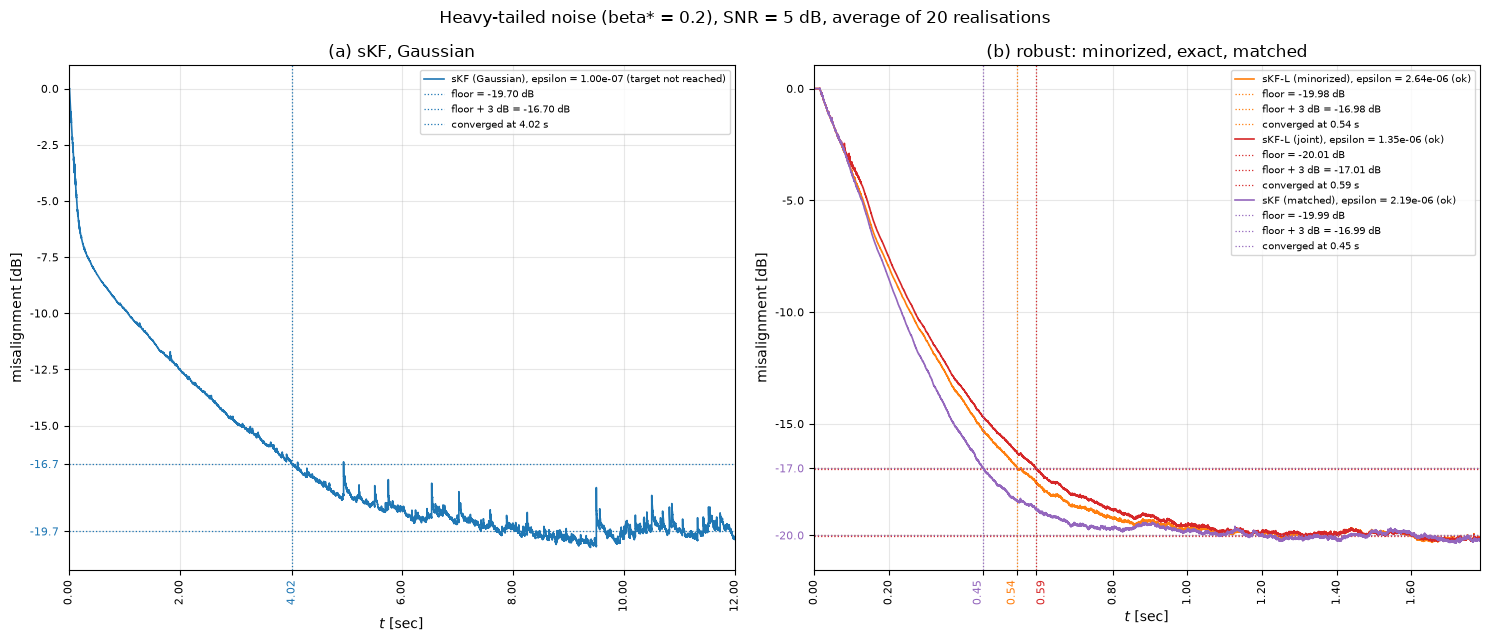

In [14]:
# Copied from notebook 07, commit f26ed36. The floors go to one decimal: the three robust
# floors sit within 0.03 dB and their labels would overlap; the legend keeps two.
FIGURE1_TITLE = (f"Heavy-tailed noise (beta* = {BETA}), SNR = {SNR_DB:.0f} dB, "
                 f"average of {R} realisations")


def draw_curve(ax, result, name, colour, style, width):
    """One curve, with its floor, its floor + 3 dB and its crossing instant dotted in its colour."""
    floor = float(result["floor"])
    reached = int(result["reached"])
    ax.plot(t_axis, 10*np.log10(result["misalignment"]), color=colour, linestyle=style,
            linewidth=width,
            label=f"{name}, {SWEPT_NAME} = {float(result['value']):.2e} ({result['status']})")
    ax.axhline(floor, color=colour, linestyle=":", linewidth=0.9,
               label=f"floor = {floor:.2f} dB")
    ax.axhline(floor + 3, color=colour, linestyle=":", linewidth=0.9,
               label=f"floor + 3 dB = {floor + 3:.2f} dB")
    ax.axvline(reached/FS, color=colour, linestyle=":", linewidth=0.9,
               label=f"converged at {reached/FS:.2f} s")
    return floor, reached


fig, (ax_gauss, ax_robust) = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, title, curves in [(ax_gauss, "(a) sKF, Gaussian", RESULTS_GAUSSIAN),
                          (ax_robust, "(b) robust: minorized, exact, matched", RESULTS_ROBUST)]:
    levels, colours_y, instants, colours_x = [], [], [], []
    slowest = 0
    for name, result, colour in curves:
        floor, reached = draw_curve(ax, result, name, colour, "-", 1.2)
        add_value(levels, colours_y, floor, colour, 1)
        add_value(levels, colours_y, floor + 3, colour, 1)
        add_value(instants, colours_x, reached/FS, colour, 2)
        slowest = max(slowest, reached)

    ax.set_xlim(0, min(3*slowest, N)/FS)               # three times the slowest convergence
    ax.set_title(title)
    ax.set_xlabel("$t$ [sec]")
    ax.set_ylabel("misalignment [dB]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
    add_ticks(ax, "y", levels, colours_y, 1, 1.5)
    add_ticks(ax, "x", instants, colours_x, 2, 0.08*ax.get_xlim()[1])

fig.suptitle(FIGURE1_TITLE)
plt.tight_layout()
plt.show()

The selected runs. Floor: mean of the last quarter of the run. Converged: first step within 3 dB of that floor.

In [15]:
print(f"{'filter':<20}{'epsilon':>11}{'floor [dB]':>12}{'steps to converge':>19}{'time [s]':>10}"
      f"{'us/step':>9}")
for name, result, colour in RESULTS:
    value = float(result["value"])
    reached = int(result["reached"])
    value_text = "-" if np.isnan(value) else f"{value:.2e}"
    steps_text = "-" if reached < 0 else str(reached)
    time_text = "-" if reached < 0 else f"{reached/FS:.2f}"
    print(f"{name:<20}{value_text:>11}{float(result['floor']):>12.2f}{steps_text:>19}"
          f"{time_text:>10}{microseconds[name]:>9.1f}")

print()
steps_matched = int(resultado_matched["reached"])
for label, result in [("joint", resultado_skf_joint), ("minorized", resultado_skf_min)]:
    steps_other = int(result["reached"])
    if steps_matched <= 0 or steps_other <= 0:
        print(f"matched / {label:<9}: one of the two never settled, no ratio")
        continue
    print(f"matched / {label:<9}: {steps_matched}/{steps_other} = {steps_matched/steps_other:.2f}x   "
          f"(floors {float(resultado_matched['floor']) - float(result['floor']):+.2f} dB apart)")

filter                  epsilon  floor [dB]  steps to converge  time [s]  us/step
sKF (Gaussian)         1.00e-07      -19.70              32148      4.02      9.0
sKF-L (minorized)      2.64e-06      -19.98               4357      0.54      8.1
sKF-L (joint)          1.35e-06      -20.01               4756      0.59     14.2
sKF (matched)          2.19e-06      -19.99               3630      0.45     66.7

matched / joint    : 3630/4756 = 0.76x   (floors +0.01 dB apart)
matched / minorized: 3630/4357 = 0.83x   (floors -0.01 dB apart)


The guard of the matched filter at its selected $\varepsilon$, realisation 0: how often $\chi_t' < 0$, how low it goes, and how much that raises $v_t$ in one step.

In [16]:
parameters = PARAMETERS_MATCHED.copy()
parameters[SWEPT_NAME] = float(resultado_matched["value"])
x, d = sweep_signals[0]
slopes = sKF_quadrature(N, x, d, w0, parameters)["chi_slope"][M:]   # from the first update on

print(f"matched filter, realisation 0, epsilon = {parameters[SWEPT_NAME]:.2e}, {len(slopes)} updates\n")
print(f"{'quantity':<34}{'value':>10}")
print(f"{'steps with chi_slope < 0':<34}{np.mean(slopes < 0):>10.2%}")
print(f"{'smallest chi_slope':<34}{slopes.min():>10.4f}")
print(f"{'largest growth of v in one step':<34}{'x' + format(1 - slopes.min()/M, '.5f'):>10}")
print("   the growth is v_t / v_tilde_t = 1 - chi'/M, eq. (36)")

matched filter, realisation 0, epsilon = 2.19e-06, 95872 updates

quantity                               value
steps with chi_slope < 0               5.98%
smallest chi_slope                   -0.9459
largest growth of v in one step     x1.00739
   the growth is v_t / v_tilde_t = 1 - chi'/M, eq. (36)


## 6. An abrupt change

The runs double to $2N$ steps and the response flips sign at the middle, $h_o \to -h_o$ at $t = N$: the first half gives every filter time to converge, the second measures how it recovers. Each filter keeps the $\varepsilon$ of section 5, so all four sit on the same floor. **Recovered:** first step after the change within 3 dB of that floor.

In [17]:
N_CHANGE = 2*N              # N steps to converge, the change, N steps to recover


def generate_signals_change(seed):
    """One realisation of 2N steps: the response flips sign at step N, theta -> -theta."""
    rng = np.random.default_rng(seed)
    u = np.sqrt(1 - AR_A**2)*rng.standard_normal(N_CHANGE + WARMUP)   # driving noise, unit-variance x
    x = lfilter([1.0], [1.0, -AR_A], u)[WARMUP:]               # x_t = AR_A x_{t-1} + u_t
    y = np.convolve(ho, x)[:N_CHANGE]                          # clean output through ho
    y[N:] = -y[N:]                                             # from step N on, through -ho
    eta = gennorm.rvs(BETA, scale=scale_gg, size=N_CHANGE, random_state=rng)
    return x, y + eta, eta


def run_change(filter_function, parameters, signals):
    """Average misalignment against theta_t: ho before step N, -ho from step N on."""
    misalignment = np.zeros(N_CHANGE)
    for x, d in signals:
        w_hist = filter_function(N_CHANGE, x, d, w0, parameters)["w_hist"]
        misalignment[:N] += ((w_hist[:N] - ho)**2).sum(axis=1)/energy_ho
        misalignment[N:] += ((w_hist[N:] + ho)**2).sum(axis=1)/energy_ho
    return misalignment/len(signals)


def change_filter(name, filter_function, fixed_parameters, value, cache_file):
    """The run across the change at the selected epsilon, for one filter. Cached in its own file."""
    if os.path.exists(cache_file):
        with np.load(cache_file) as stored:
            if (np.isclose(float(stored["value"]), value, rtol=1e-12)
                    and int(stored["R"]) == R and int(stored["N"]) == N_CHANGE):
                print(f"{name:<20} loaded from {cache_file}")
                return stored["misalignment"]
        print(f"{name:<20} {cache_file} was computed at another epsilon, R or N: computing again")
    parameters = fixed_parameters.copy()
    parameters[SWEPT_NAME] = value
    start = time.time()
    misalignment = run_change(filter_function, parameters, change_signals)
    np.savez(cache_file, misalignment=misalignment, value=value, R=R, N=N_CHANGE)
    print(f"{name:<20} done in {(time.time() - start)/60:.1f} min, saved to {cache_file}")
    return misalignment


change_signals = []
for seed in range(R):
    x, d, eta = generate_signals_change(seed)
    change_signals.append((x, d))

CHANGE_PREFIX = f"../cache/09_change_gg020_n{N_NODES}_mad_"
CHANGE_FILES = {"sKF (Gaussian)": CHANGE_PREFIX + "skf_gauss.npz",
                "sKF-L (minorized)": CHANGE_PREFIX + "skf_min.npz",
                "sKF-L (joint)": CHANGE_PREFIX + "skf_joint.npz",
                "sKF (matched)": CHANGE_PREFIX + "skf_matched.npz"}
change_runs = {}
for name, filter_function, fixed_parameters, result in [
        ("sKF (Gaussian)", sKF_gaussian, PARAMETERS_SKF_GAUSS, resultado_skf_gauss),
        ("sKF-L (minorized)", sKF_L_minorized, PARAMETERS_SKF_L, resultado_skf_min),
        ("sKF-L (joint)", sKF_L_joint, PARAMETERS_SKF_L, resultado_skf_joint),
        ("sKF (matched)", sKF_quadrature, PARAMETERS_MATCHED, resultado_matched)]:
    change_runs[name] = change_filter(name, filter_function, fixed_parameters,
                                      float(result["value"]), CHANGE_FILES[name])

sKF (Gaussian)       loaded from ../cache/09_change_gg020_n100_mad_skf_gauss.npz
sKF-L (minorized)    loaded from ../cache/09_change_gg020_n100_mad_skf_min.npz
sKF-L (joint)        loaded from ../cache/09_change_gg020_n100_mad_skf_joint.npz
sKF (matched)        loaded from ../cache/09_change_gg020_n100_mad_skf_matched.npz


In [18]:
def recovery(misalignment, floor):
    """Steps from the change until the misalignment is back within 3 dB of the floor at rest;
    -1 if it never gets there before the run ends."""
    db = 10*np.log10(misalignment[N:])
    back = db < floor + 3
    if not back.any():
        return -1
    return int(np.argmax(back))


recovered = {}
print(f"{'filter':<20}{'floor at rest [dB]':>20}{'steps to recover':>18}{'time [s]':>18}")
for name, result, colour in RESULTS:
    floor = float(result["floor"])
    recovered[name] = recovery(change_runs[name], floor)
    steps_text = "-" if recovered[name] < 0 else str(recovered[name])
    time_text = f"not within {N/FS:.0f} s" if recovered[name] < 0 else f"{recovered[name]/FS:.2f}"
    print(f"{name:<20}{floor:>20.2f}{steps_text:>18}{time_text:>18}")

print()
for label, name in [("joint", "sKF-L (joint)"), ("minorized", "sKF-L (minorized)")]:
    if recovered["sKF (matched)"] <= 0 or recovered[name] <= 0:
        print(f"matched / {label:<9}: one of the two never recovered, no ratio")
        continue
    print(f"matched / {label:<9}: {recovered['sKF (matched)']}/{recovered[name]} = "
          f"{recovered['sKF (matched)']/recovered[name]:.2f}x")
print("Section 4 of the new draft quotes 1.2 to 2.2x for the matched filter against the Laplacian ones")

filter                floor at rest [dB]  steps to recover          time [s]
sKF (Gaussian)                    -19.70             67693              8.46
sKF-L (minorized)                 -19.98              7340              0.92
sKF-L (joint)                     -20.01              7584              0.95
sKF (matched)                     -19.99              5979              0.75

matched / joint    : 5979/7584 = 0.79x
matched / minorized: 5979/7340 = 0.81x
Section 4 of the new draft quotes 1.2 to 2.2x for the matched filter against the Laplacian ones


**Figure 2.** Misalignment across the change, time counted from it: (a) the Gaussian sKF, (b) the three robust filters. Dotted, in each curve's colour: its floor at rest, that floor $+\,3$ dB and the instant it gets back there. Black, dotted: the change.

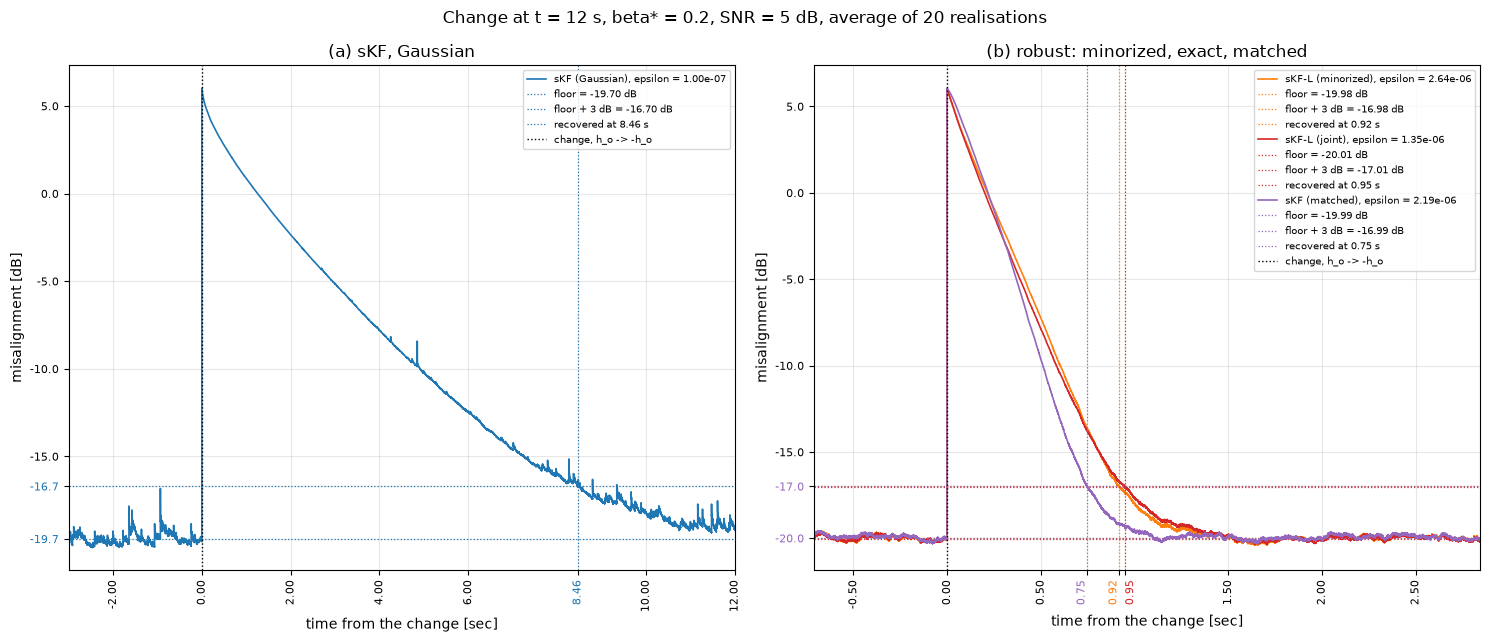

whole notebook: 0.3 min


In [19]:
fig, (ax_gauss, ax_robust) = plt.subplots(1, 2, figsize=(15, 6.5))
t_change = (np.arange(N_CHANGE) - N)/FS            # seconds from the change

for ax, title, curves in [(ax_gauss, "(a) sKF, Gaussian", RESULTS_GAUSSIAN),
                          (ax_robust, "(b) robust: minorized, exact, matched", RESULTS_ROBUST)]:
    levels, colours_y, instants, colours_x = [], [], [], []
    slowest = 0
    for name, result, colour in curves:
        floor = float(result["floor"])
        ax.plot(t_change, 10*np.log10(change_runs[name]), color=colour, linewidth=1.2,
                label=f"{name}, {SWEPT_NAME} = {float(result['value']):.2e}")
        ax.axhline(floor, color=colour, linestyle=":", linewidth=0.9, label=f"floor = {floor:.2f} dB")
        ax.axhline(floor + 3, color=colour, linestyle=":", linewidth=0.9,
                   label=f"floor + 3 dB = {floor + 3:.2f} dB")
        add_value(levels, colours_y, floor, colour, 1)     # one decimal: the floors sit within
        add_value(levels, colours_y, floor + 3, colour, 1) # 0.03 dB, the legend keeps two
        if recovered[name] > 0:
            ax.axvline(recovered[name]/FS, color=colour, linestyle=":", linewidth=0.9,
                       label=f"recovered at {recovered[name]/FS:.2f} s")
            add_value(instants, colours_x, recovered[name]/FS, colour, 2)
            slowest = max(slowest, recovered[name])
        else:
            slowest = N                                # never recovered: show the whole second half
    ax.axvline(0.0, color="k", linestyle=":", linewidth=1.0, label="change, h_o -> -h_o")
    ax.set_xlim(-0.25*min(3*slowest, N)/FS, min(3*slowest, N)/FS)
    ax.set_title(title)
    ax.set_xlabel("time from the change [sec]")
    ax.set_ylabel("misalignment [dB]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
    add_ticks(ax, "y", levels, colours_y, 1, 1.5)
    if instants:                                       # no tick to add if none recovered
        add_ticks(ax, "x", instants, colours_x, 2, 0.08*ax.get_xlim()[1])

fig.suptitle(f"Change at t = {N/FS:.0f} s, beta* = {BETA}, SNR = {SNR_DB:.0f} dB, average of {R} realisations")
plt.tight_layout()
plt.show()

print(f"whole notebook: {(time.time() - NOTEBOOK_START)/60:.1f} min")

## 7. Summary

Each filter at the $\varepsilon$ that lands its floor on $-20$ dB: the steps to converge from zero, and the steps to recover after $h_o \to -h_o$.

In [20]:
print(f"{'filter':<20}{'epsilon':>11}{'floor [dB]':>12}{'steps to converge':>19}{'steps to recover':>18}")
for name, result, colour in RESULTS:
    reached = int(result["reached"])
    converge_text = "-" if reached < 0 else str(reached)
    recover_text = "-" if recovered[name] < 0 else str(recovered[name])
    print(f"{name:<20}{float(result['value']):>11.2e}{float(result['floor']):>12.2f}"
          f"{converge_text:>19}{recover_text:>18}")

print()
steps_matched = int(resultado_matched["reached"])
for label, name, result in [("joint", "sKF-L (joint)", resultado_skf_joint),
                            ("minorized", "sKF-L (minorized)", resultado_skf_min)]:
    print(f"matched / {label:<9}: at rest {steps_matched/int(result['reached']):.2f}x, "
          f"recovering {recovered['sKF (matched)']/recovered[name]:.2f}x")
print("Section 4 of the new draft quotes 1.2 to 2.2x for the matched filter against the Laplacian ones")

filter                  epsilon  floor [dB]  steps to converge  steps to recover
sKF (Gaussian)         1.00e-07      -19.70              32148             67693
sKF-L (minorized)      2.64e-06      -19.98               4357              7340
sKF-L (joint)          1.35e-06      -20.01               4756              7584
sKF (matched)          2.19e-06      -19.99               3630              5979

matched / joint    : at rest 0.76x, recovering 0.79x
matched / minorized: at rest 0.83x, recovering 0.81x
Section 4 of the new draft quotes 1.2 to 2.2x for the matched filter against the Laplacian ones


## Appendix: technical checks

What the tables above leave out, computed the same way.

Every grid point, then the discarded count. A warning means the deepest settled point sits on a grid edge, where the curve is cut and the grid has to widen.

In [21]:
print(f"{'filter':<20}{'epsilon':>11}{'floor [dB]':>12}{'steps':>8}  point")
for name, result, colour in RESULTS:
    for value, floor, step, ok in zip(result["grid"], result["floors"],
                                      result["steps"], result["settled"]):
        print(f"{name:<20}{value:>11.1e}{floor:>12.2f}{step:>8}  "
              f"{'settled' if ok else 'not settled'}")

print()
for name, result, colour in RESULTS:
    floors, settled = result["floors"], result["settled"]
    print(f"{name:<20} {int(np.sum(~settled))} of {len(floors)} grid points discarded "
          f"as not settled")
    if not settled.any():
        print("   WARNING: no grid point settled")
        continue
    best = np.flatnonzero(settled)[np.argmin(floors[settled])]
    if best in (0, len(floors) - 1):
        print(f"   WARNING: its best point, {SWEPT_NAME} = {result['grid'][best]:.1e}, "
              f"is on the edge of the grid")

filter                  epsilon  floor [dB]   steps  point
sKF (Gaussian)          1.0e-11      -10.41    2761  settled
sKF (Gaussian)          3.2e-11      -10.47    2873  settled
sKF (Gaussian)          1.0e-10      -10.65    3246  settled
sKF (Gaussian)          3.2e-10      -11.10    4593  not settled
sKF (Gaussian)          1.0e-09      -12.09   12888  not settled
sKF (Gaussian)          3.2e-09      -13.98   36562  not settled
sKF (Gaussian)          1.0e-08      -17.04   52161  not settled
sKF (Gaussian)          3.2e-08      -20.17   53188  not settled
sKF (Gaussian)          1.0e-07      -19.70   32148  settled
sKF (Gaussian)          3.2e-07      -17.20   15709  settled
sKF (Gaussian)          1.0e-06      -14.58    6689  settled
sKF-L (minorized)       1.0e-08      -38.89   73359  not settled
sKF-L (minorized)       3.2e-08      -38.25   43297  settled
sKF-L (minorized)       1.0e-07      -33.52   22730  settled
sKF-L (minorized)       3.2e-07      -28.71   12412  settled
sK

$k_t = \sigma_t/\mathrm{E}|\eta_t|$ of each selected run, over realisation 0, and the status of its search. Then the control: the Gaussian, the minorized and the joint filter must repeat notebook 07.

In [22]:
# Copied from notebook 07, commit f26ed36.
def k_summary(filter_function, parameters):
    """k_t = sigma_t / E|eta| over one run on realisation 0: median, 10th and 90th percentiles."""
    x, d = sweep_signals[0]
    sigma = filter_function(N, x, d, w0, parameters)["sigma"][M:]   # from the first update on
    k_t = sigma/b_eta                                  # E|eta| for every filter: one axis for all
    return {"median": np.median(k_t), "p10": np.percentile(k_t, 10), "p90": np.percentile(k_t, 90)}


# k_t of each filter at its selected epsilon.
k_runs = {}
for name, filter_function, fixed_parameters, result in [
        ("sKF (Gaussian)", sKF_gaussian, PARAMETERS_SKF_GAUSS, resultado_skf_gauss),
        ("sKF-L (minorized)", sKF_L_minorized, PARAMETERS_SKF_L, resultado_skf_min),
        ("sKF-L (joint)", sKF_L_joint, PARAMETERS_SKF_L, resultado_skf_joint),
        ("sKF (matched)", sKF_quadrature, PARAMETERS_MATCHED, resultado_matched)]:
    parameters = fixed_parameters.copy()
    parameters[SWEPT_NAME] = float(result["value"])
    if np.isnan(parameters[SWEPT_NAME]):
        k_runs[name] = {"median": np.nan, "p10": np.nan, "p90": np.nan}
    else:
        k_runs[name] = k_summary(filter_function, parameters)

print(f"{'filter':<20}{'k_t median':>12}{'k_t 10-90%':>16}  status")
for name, result, colour in RESULTS:
    k_range = f"{k_runs[name]['p10']:.3f}-{k_runs[name]['p90']:.3f}"
    print(f"{name:<20}{k_runs[name]['median']:>12.3f}{k_range:>16}  {result['status']}")

# Control: the Gaussian, the minorized and the joint filter run exactly as in notebook 07, on
# the same signals, grids and protocol, so they must repeat its numbers (commit f26ed36).
CONTROL_07 = {}
CONTROL_07["sKF (Gaussian)"] = {"value": 1.000000e-07, "floor": -19.7028, "steps": 32148}
CONTROL_07["sKF-L (minorized)"] = {"value": 2.641249e-06, "floor": -19.9839, "steps": 4357}
CONTROL_07["sKF-L (joint)"] = {"value": 1.349260e-06, "floor": -20.0067, "steps": 4756}
print()
print("control against notebook 07 (same signals, grids and protocol):")
for name, result, colour in RESULTS[:3]:
    reference = CONTROL_07[name]
    same = (np.isclose(float(result["value"]), reference["value"], rtol=1e-5)
            and int(result["reached"]) == reference["steps"])
    print(f"   {name:<20} epsilon {float(result['value']):.4e} / {reference['value']:.4e}, "
          f"steps {int(result['reached'])} / {reference['steps']}   {'same' if same else 'DIFFERENT'}")

filter                k_t median      k_t 10-90%  status
sKF (Gaussian)             1.121     0.893-1.440  target not reached
sKF-L (minorized)          1.782     1.428-2.279  ok
sKF-L (joint)              1.484     1.197-1.884  ok
sKF (matched)              1.646     1.315-2.107  ok

control against notebook 07 (same signals, grids and protocol):
   sKF (Gaussian)       epsilon 1.0000e-07 / 1.0000e-07, steps 32148 / 32148   same
   sKF-L (minorized)    epsilon 2.6412e-06 / 2.6412e-06, steps 4357 / 4357   same
   sKF-L (joint)        epsilon 1.3493e-06 / 1.3493e-06, steps 4756 / 4756   same


The largest $\chi_t'$ of that same run: at most 1, so the assert of `sKF_quadrature` never fired.

In [23]:
print(f"largest chi'  : {slopes.max():.6f}   (at most 1: the assert never fired)")

largest chi'  : 0.998666   (at most 1: the assert never fired)


Before the change: every filter had converged, its last quarter before the change within 3 dB of its floor at rest.

In [24]:
print(f"{'filter':<20}{'floor at rest [dB]':>20}{'before [dB]':>13}  converged")
for name, result, colour in RESULTS:
    floor = float(result["floor"])
    before = 10*np.log10(change_runs[name][3*N//4:N].mean())   # last quarter before the change
    print(f"{name:<20}{floor:>20.2f}{before:>13.2f}  {'yes' if before <= floor + 3 else 'NO'}")
print("   floor: section 5, at rest; before: mean of the last quarter before the change, same run")

filter                floor at rest [dB]  before [dB]  converged
sKF (Gaussian)                    -19.70       -19.69  yes
sKF-L (minorized)                 -19.98       -20.01  yes
sKF-L (joint)                     -20.01       -20.02  yes
sKF (matched)                     -19.99       -19.96  yes
   floor: section 5, at rest; before: mean of the last quarter before the change, same run
